In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [39]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/shopify_stock.csv')

In [40]:
df.head(5)

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [41]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

In [42]:
df.dtypes

,0
date,object
open,float64
high,float64
low,float64
close,float64
adj_close,float64
volume,int64


In [43]:
df["date"] = pd.to_datetime(df["date"],utc=True)
df['date'].dtype

datetime64[ns, UTC]

In [44]:
df = df.sort_values("date")

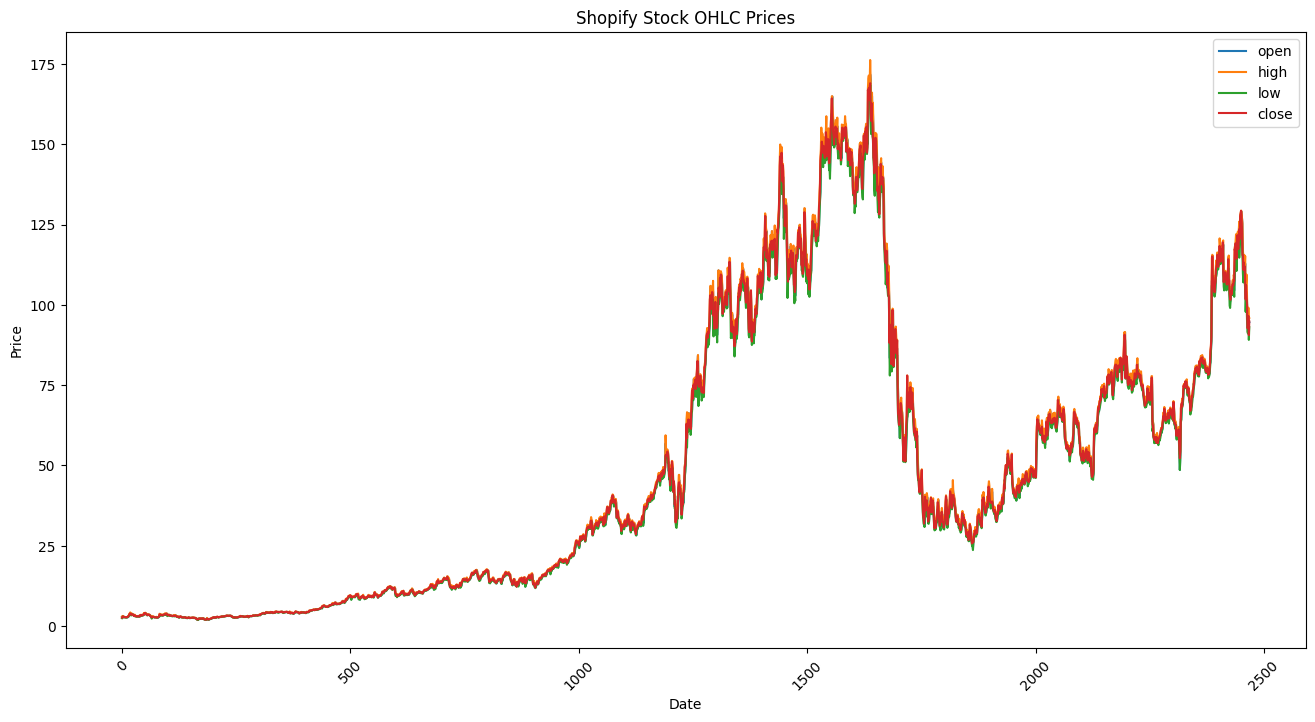

In [45]:
plt.figure(figsize=(16, 8))

plt.plot(df.index, df["open"], label="open")
plt.plot(df.index, df["high"], label="high")
plt.plot(df.index, df["low"], label="low")
plt.plot(df.index, df["close"], label="close")

plt.title("Shopify Stock OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

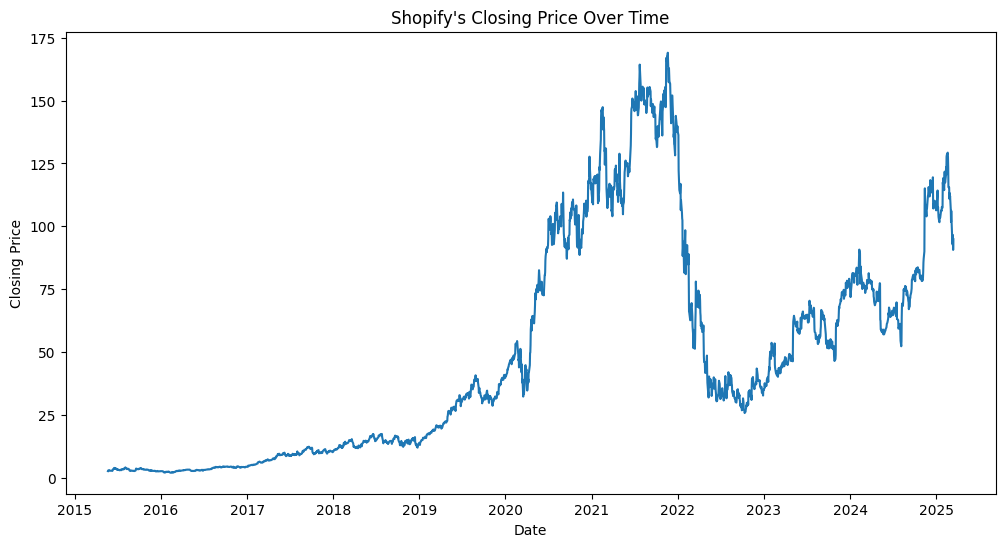

In [46]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='close', data=df)
plt.title("Shopify's Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

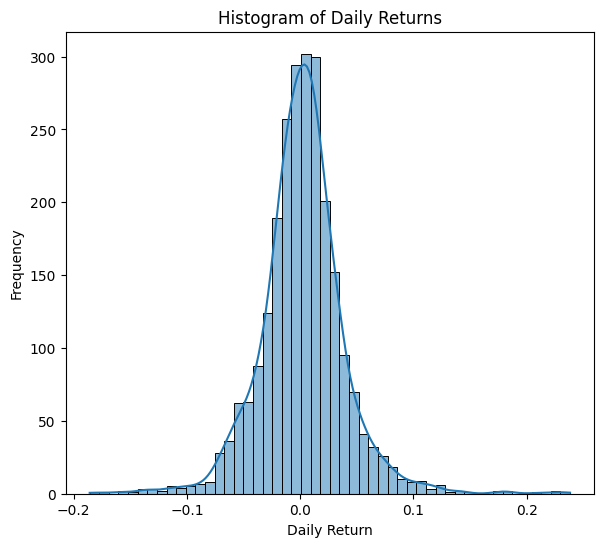

In [47]:
df['daily_returns'] = df['close'].pct_change()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['daily_returns'].dropna(), bins=50, kde=True)
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

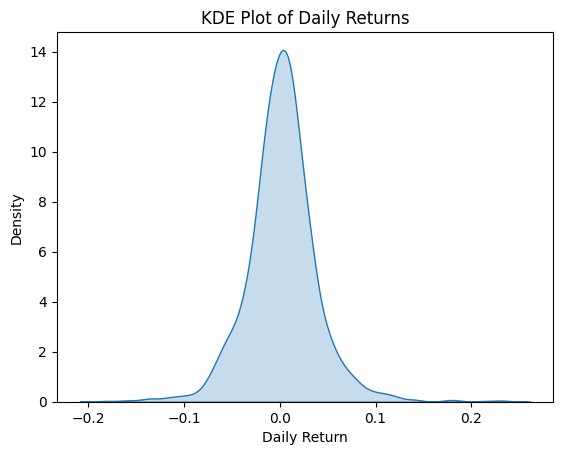

In [48]:
sns.kdeplot(df['daily_returns'].dropna(), fill=True)
plt.title('KDE Plot of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.show()

In [49]:
df["Rolling_Volatility_20"] = (df["daily_returns"].rolling(window=20).std())

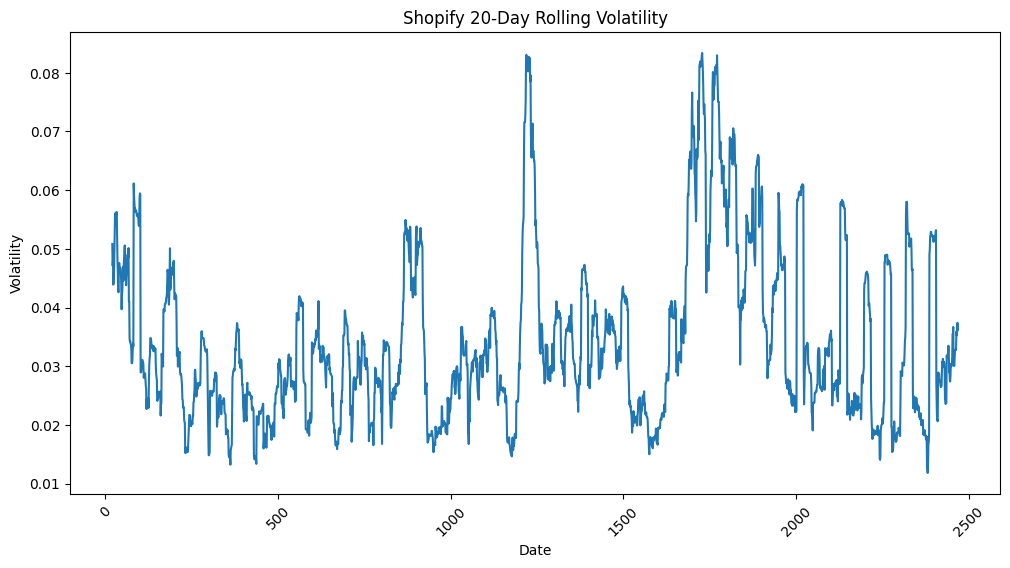

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(df.index,df["Rolling_Volatility_20"])

plt.title("Shopify 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.show()